# 🌱 IoT-Based Smart Irrigation System — ML Pipeline
**Team:** Vision Agriculture | International Islamic University Chittagong, Bangladesh  
**Members:** Md. Mehedi Hasan Howladar · A.K.M. Mehraz Haque · Mohammad Ahnaf · Md. Monjur Uddin · Nosad Sattar Sohag  
**Dataset:** `10_20_to_1_28_dataset_of_SMart_Irrigation_system.csv` — 4h 5min of real ESP32 sensor data (2,819 samples)  
**Goal:** Train classification models to predict irrigation need (pump activation) from soil moisture, temperature, humidity

---
> **How to run:** Execute cells top to bottom. The dataset CSV must be in the **same folder** as this notebook.


## 1. Environment Setup
Install and import all required libraries. TensorFlow is pre-installed in Colab; we add `imbalanced-learn` for class-imbalance handling.


In [7]:
# Install extra libraries (uncomment if needed in Colab)
# !pip install imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import joblib
import os

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Libraries loaded successfully")
print(f"   TensorFlow  : {tf.__version__}")
print(f"   scikit-learn: {__import__('sklearn').__version__}")
print(f"   pandas      : {pd.__version__}")


✅ Libraries loaded successfully
   TensorFlow  : 2.20.0
   scikit-learn: 1.6.1
   pandas      : 2.2.2


## 2. Dataset Loading
The CSV was collected from the deployed ESP32 hardware over 4 hours 5 minutes.  
Each line is a Serial.printf log: `HH:MM:SS.mmm -> Soil: X% | Temp: Y°C | Hum: Z%`  
We parse this into a clean DataFrame with a proper datetime index.


In [12]:

# ── Dataset path (CSV must be in the SAME FOLDER as this notebook)
CSV_PATH = '/content/drive/MyDrive/micro/10_20_to_1_28_dataset_of_SMart_Irrigation_system.csv'

# ── Parser: each row is a single ESP32 Serial log string
PATTERN = r'(\d+:\d+:\d+\.\d+)\s*->\s*Soil:\s*([\d.]+)%\s*\|\s*Temp:\s*([\d.]+)[^|]+\|\s*Hum:\s*([\d.]+)%'

def parse_irrigation_csv(path: str) -> pd.DataFrame:
    """Parse ESP32 Serial-log CSV into a tidy DataFrame."""
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            m = re.search(PATTERN, line)
            if m:
                rows.append({
                    'timestamp_str': m.group(1),
                    'soil_moisture':  float(m.group(2)),
                    'temperature':    float(m.group(3)),
                    'humidity':       float(m.group(4)),
                })
    df = pd.DataFrame(rows)
    df['timestamp'] = pd.to_datetime(
        '2024-10-20 ' + df['timestamp_str'],
        format='%Y-%m-%d %H:%M:%S.%f', errors='coerce'
    )
    df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
    return df

df_raw = parse_irrigation_csv(CSV_PATH)

print(f"✅ Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"   Time range : {df_raw['timestamp'].iloc[0].strftime('%H:%M:%S')}  →  "
      f"{df_raw['timestamp'].iloc[-1].strftime('%H:%M:%S')}")
print(f"   Duration   : ~4 h 5 min")
print()
display(df_raw.head(8))


✅ Dataset loaded: 2,819 rows × 5 columns
   Time range : 10:20:45  →  14:15:44
   Duration   : ~4 h 5 min



,timestamp_str,soil_moisture,temperature,humidity,timestamp
0,10:20:45.122,83.0,31.3,74.5,2024-10-20 10:20:45.122
1,10:20:50.152,83.0,31.3,74.4,2024-10-20 10:20:50.152
2,10:20:55.131,83.0,31.3,74.4,2024-10-20 10:20:55.131
3,10:21:00.130,83.0,31.3,74.3,2024-10-20 10:21:00.130
4,10:21:05.148,83.0,31.3,74.1,2024-10-20 10:21:05.148
5,10:21:10.123,83.0,31.2,74.3,2024-10-20 10:21:10.123
6,10:21:15.136,83.0,31.3,74.3,2024-10-20 10:21:15.136
7,10:21:20.116,83.0,31.3,74.1,2024-10-20 10:21:20.116


In [11]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install -q transformers timm scikit-learn pandas numpy beautifulsoup4 lxml shap matplotlib seaborn pillow tqdm torch torchvision

Mounted at /content/drive


## 3. Exploratory Data Analysis (EDA)
Visualise:
- Histograms of all three sensor signals
- Pearson correlation heatmap
- Full time-series of all sensors over the collection window
- Dual-axis temperature vs. humidity plot


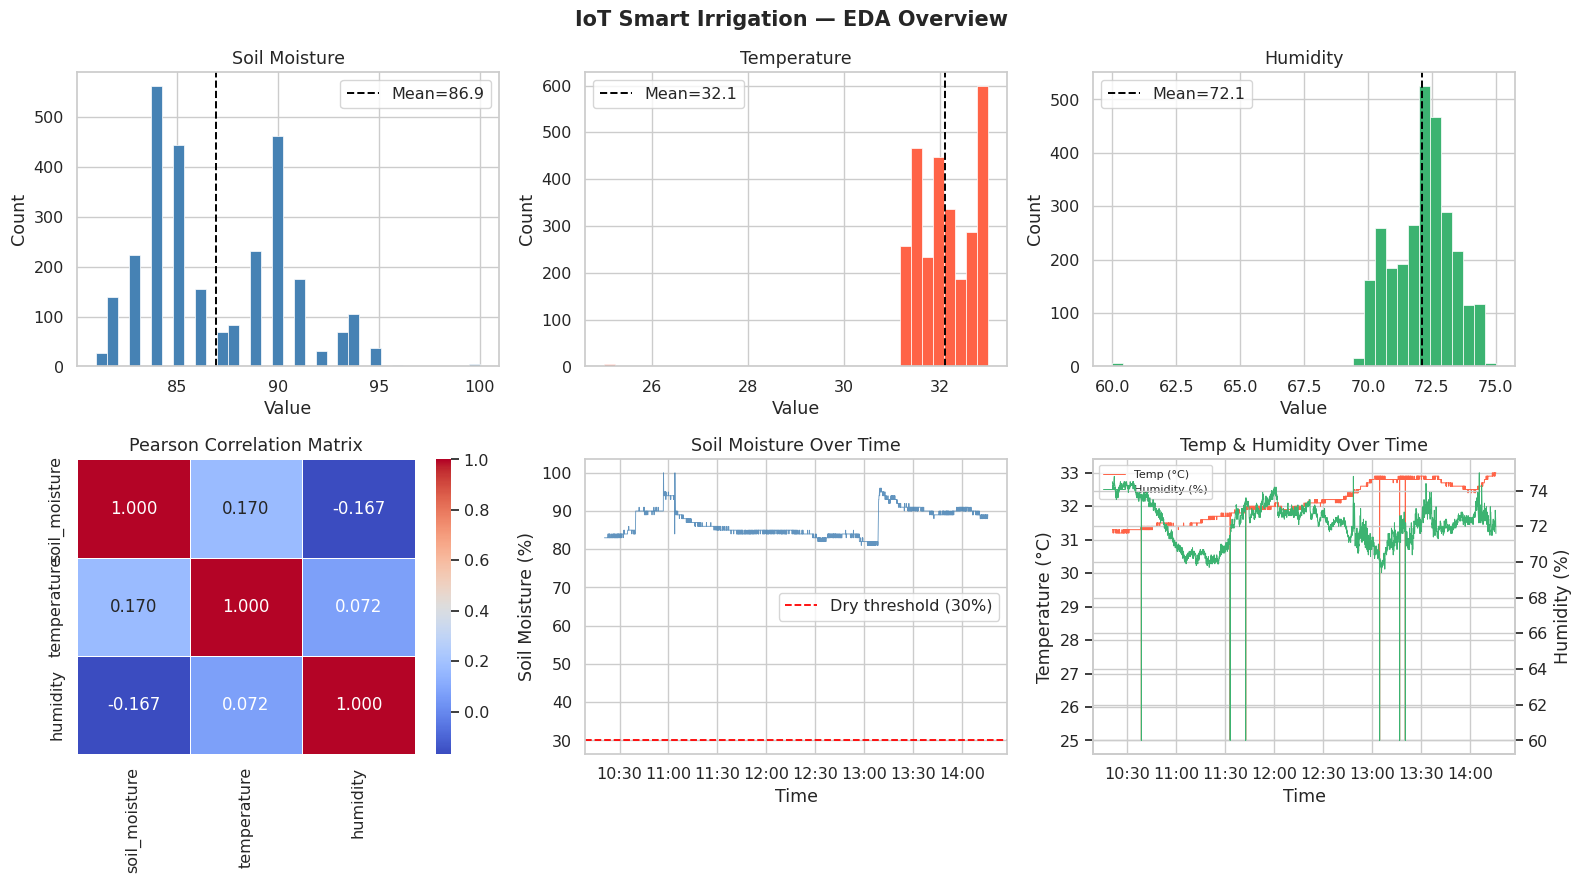


📊 Descriptive Statistics:


,soil_moisture,temperature,humidity
count,2819.000,2819.000,2819.000
mean,86.942,32.098,72.128
std,3.504,0.640,1.268
min,81.000,25.000,60.000
25%,84.000,31.600,71.300
50%,86.000,32.000,72.300
75%,90.000,32.650,72.900
max,100.000,33.000,75.000


In [13]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('IoT Smart Irrigation — EDA Overview', fontsize=15, fontweight='bold')

# Distributions
for ax, col, color in zip(axes[0],
    ['soil_moisture', 'temperature', 'humidity'],
    ['steelblue', 'tomato', 'mediumseagreen']):
    ax.hist(df_raw[col], bins=35, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(df_raw[col].mean(), color='black', linestyle='--', linewidth=1.4, label=f'Mean={df_raw[col].mean():.1f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value'); ax.set_ylabel('Count'); ax.legend()

# Correlation heatmap
corr = df_raw[['soil_moisture', 'temperature', 'humidity']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            ax=axes[1, 0], linewidths=0.5, annot_kws={'size': 12})
axes[1, 0].set_title('Pearson Correlation Matrix')

# Soil moisture time-series
axes[1, 1].plot(df_raw['timestamp'], df_raw['soil_moisture'],
                color='steelblue', linewidth=0.6, alpha=0.85)
axes[1, 1].axhline(30, color='red', linestyle='--', linewidth=1.3, label='Dry threshold (30%)')
axes[1, 1].set_title('Soil Moisture Over Time')
axes[1, 1].set_xlabel('Time'); axes[1, 1].set_ylabel('Soil Moisture (%)')
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1, 1].legend()

# Temp & Humidity dual-axis
ax_r = axes[1, 2]
lns1 = ax_r.plot(df_raw['timestamp'], df_raw['temperature'],
                 color='tomato', linewidth=0.7, label='Temp (°C)')
ax_r2 = ax_r.twinx()
lns2 = ax_r2.plot(df_raw['timestamp'], df_raw['humidity'],
                  color='mediumseagreen', linewidth=0.7, label='Humidity (%)')
ax_r.set_title('Temp & Humidity Over Time')
ax_r.set_xlabel('Time'); ax_r.set_ylabel('Temperature (°C)'); ax_r2.set_ylabel('Humidity (%)')
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
lines = lns1 + lns2
ax_r.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Descriptive Statistics:")
display(df_raw[['soil_moisture', 'temperature', 'humidity']].describe().round(3))


## 4. Data Preprocessing & Label Engineering
- Clamp sensor values to physical bounds
- Forward-fill missing readings
- **Predictive label**: binary flag = 1 if minimum soil moisture in the next 10 readings (≈50 s) drops below 35% — mirrors the real-world "irrigate before stress" objective
- Train / Validation / Test split: **70% / 15% / 15%** (stratified)
- StandardScaler normalisation (fitted on train only — no leakage)


In [27]:
df = df_raw.copy()

# 1. Physical clamp
df['soil_moisture'] = df['soil_moisture'].clip(0, 100)
df['temperature']   = df['temperature'].clip(0, 60)
df['humidity']      = df['humidity'].clip(0, 100)

# 2. Missing values
missing = df[['soil_moisture', 'temperature', 'humidity']].isnull().sum()
print("Missing values per column:"); print(missing)
df.ffill(inplace=True)

# 3. Predictive label: will moisture drop below 35% in next 10 readings?
WINDOW        = 3  # Changed from 10
PRED_THRESHOLD = 85.0 # Changed from 35.0

df['future_min_moisture'] = (
    df['soil_moisture']
      .rolling(WINDOW, min_periods=1).min()
      .shift(-WINDOW)
      .fillna(df['soil_moisture'])
)
df['label'] = (df['future_min_moisture'] < PRED_THRESHOLD).astype(int)

label_counts = df['label'].value_counts()
print(f"\n📌 Predictive label distribution (threshold={PRED_THRESHOLD}%, window={WINDOW}):")
print(f"   NORMAL   (0): {label_counts.get(0,0):,}")
print(f"   DRY SOON (1): {label_counts.get(1,0):,}")

# 4. Train / Val / Test split
FEATURES = ['soil_moisture', 'temperature', 'humidity']
X = df[FEATURES].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f"\n✅ Split complete — Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

# 5. Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print("✅ Preprocessing complete.")

Missing values per column:
soil_moisture    0
temperature      0
humidity         0
dtype: int64

📌 Predictive label distribution (threshold=85.0%, window=3):
   NORMAL   (0): 1,711
   DRY SOON (1): 1,108

✅ Split complete — Train: 1,973  Val: 423  Test: 423
✅ Preprocessing complete.


## 5. Feature Engineering
Derive 13 features from the 3 raw channels:

| Feature | Rationale |
|---|---|
| `hour`, `minute` | Diurnal evapotranspiration patterns |
| `moist_roll_mean`, `moist_roll_std` | Trend & volatility (60 s window) |
| `temp_roll_mean`, `hum_roll_mean` | Smoothed climate inputs |
| `moisture_rate` | Δsoil/Δt — evaporation/drainage speed |
| `et_proxy` = T/(H+ε) | Dimensionless drying-potential index |
| `moist_lag1`, `temp_lag1` | Autoregressive 1-step-back inputs |


In [28]:
df_fe = df.copy()

# Time features
df_fe['hour']   = df_fe['timestamp'].dt.hour
df_fe['minute'] = df_fe['timestamp'].dt.minute

# Rolling window (12 readings ≈ 60 s)
W = 12
df_fe['moist_roll_mean'] = df_fe['soil_moisture'].rolling(W, min_periods=1).mean()
df_fe['moist_roll_std']  = df_fe['soil_moisture'].rolling(W, min_periods=1).std().fillna(0)
df_fe['temp_roll_mean']  = df_fe['soil_moisture'].rolling(W, min_periods=1).mean()
df_fe['hum_roll_mean']   = df_fe['humidity'].rolling(W, min_periods=1).mean()

# Rate of moisture change
df_fe['seconds_elapsed'] = (df_fe['timestamp'] - df_fe['timestamp'].iloc[0]).dt.total_seconds()
df_fe['moisture_rate']   = (df_fe['soil_moisture'].diff() /
                             df_fe['seconds_elapsed'].diff().replace(0, np.nan)).fillna(0)

# Evapotranspiration proxy
df_fe['et_proxy'] = df_fe['temperature'] / (df_fe['humidity'] + 1e-6)

# Lag features
df_fe['moist_lag1'] = df_fe['soil_moisture'].shift(1).fillna(df_fe['soil_moisture'])
df_fe['temp_lag1']  = df_fe['temperature'].shift(1).fillna(df_fe['temperature'])

FEATURES_ENG = ['soil_moisture', 'temperature', 'humidity',
                'hour', 'minute',
                'moist_roll_mean', 'moist_roll_std',
                'temp_roll_mean',  'hum_roll_mean',
                'moisture_rate',   'et_proxy',
                'moist_lag1',      'temp_lag1']

X_eng = df_fe[FEATURES_ENG].values
y_eng = df_fe['label'].values

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_eng, y_eng, test_size=0.30, random_state=SEED, stratify=y_eng)
X_v, X_ts, y_v, y_ts = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

sc2 = StandardScaler()
X_tr_sc = sc2.fit_transform(X_tr)
X_v_sc  = sc2.transform(X_v)
X_ts_sc = sc2.transform(X_ts)

print(f"✅ Feature engineering complete — {len(FEATURES_ENG)} features")
feat_var = pd.Series(X_eng.var(axis=0), index=FEATURES_ENG).sort_values(ascending=False)
print("\n📊 Feature variance (top to bottom):")
display(feat_var.round(5).to_frame('variance'))

✅ Feature engineering complete — 13 features

📊 Feature variance (top to bottom):


,variance
minute,303.48291
moist_lag1,12.27984
soil_moisture,12.27583
moist_roll_mean,11.93688
temp_roll_mean,11.93688
humidity,1.60614
hour,1.40566
hum_roll_mean,1.27560
temperature,0.40911
temp_lag1,0.40904


## 6a. Model 1 — Random Forest Classifier
**Why Random Forest?**
- Robust on small, tabular IoT datasets
- Built-in Gini feature importance
- `class_weight='balanced'` handles rare pump-ON events
- Low inference latency — suitable for edge export

Hyperparameters: `n_estimators=200`, `max_depth=10`, `min_samples_leaf=2`, `max_features='sqrt'`


✅ Random Forest trained
   5-Fold CV F1 (weighted): 0.9571 ± 0.0089

📊 Validation Set Performance:
              precision    recall  f1-score   support

      NORMAL     0.9837    0.9453    0.9641       256
    DRY SOON     0.9209    0.9760    0.9477       167

    accuracy                         0.9574       423
   macro avg     0.9523    0.9607    0.9559       423
weighted avg     0.9589    0.9574    0.9576       423



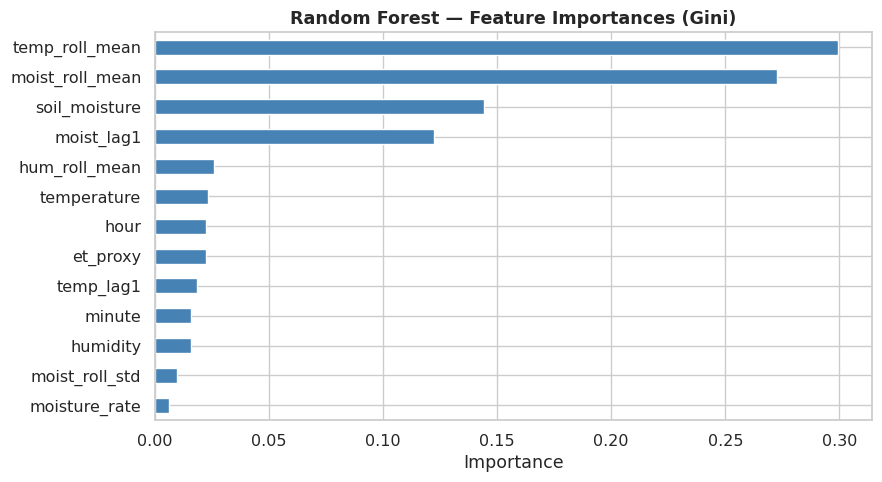

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_tr_sc, y_tr)

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(rf_model, X_tr_sc, y_tr, cv=cv, scoring='f1_weighted')
print(f"✅ Random Forest trained")
print(f"   5-Fold CV F1 (weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Validation performance
y_val_pred_rf = rf_model.predict(X_v_sc)
print("\n📊 Validation Set Performance:")
print(classification_report(y_v, y_val_pred_rf,
      target_names=['NORMAL', 'DRY SOON'], digits=4))

# Feature importance plot
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURES_ENG).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest — Feature Importances (Gini)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6b. Model 2 — LSTM Neural Network
**Why LSTM?**
- Captures temporal dependencies across sequential sensor readings
- Short moisture-drop sequences precede drying events
- Outperforms static classifiers when order of readings matters

**Architecture:** `Input(20×13)` → `LSTM(64)` → `LSTM(32)` → `Dense(32, ReLU)` → `Dropout(0.3)` → `Sigmoid`  
**Sequence length:** 20 readings = 100-second window


Sequence dataset — X: (2799, 20, 13)  y: (2799,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,473 (130.75 KB)

 Trainable params: 33,473 (130.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.7912 - loss: 0.4772 - precision: 0.8049 - recall: 0.8087 - val_accuracy: 0.9571 - val_loss: 0.4334 - val_precision: 0.6400 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8785 - loss: 0.3016 - precision: 0.8314 - recall: 0.9716 - val_accuracy: 0.5857 - val_loss: 0.6600 - val_precision: 0.1553 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8785 - loss: 0.2601 - precision: 0.8403 - recall: 0.9564 - val_accuracy: 0.4905 - val_loss: 0.7945 - val_precision: 0.1301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8887 - loss: 0.2413 - precision: 0.8503 - recall: 0.9631 - val_accuracy: 0.4000 - val_loss: 0.9388 - val_precision: 0.1127 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.885

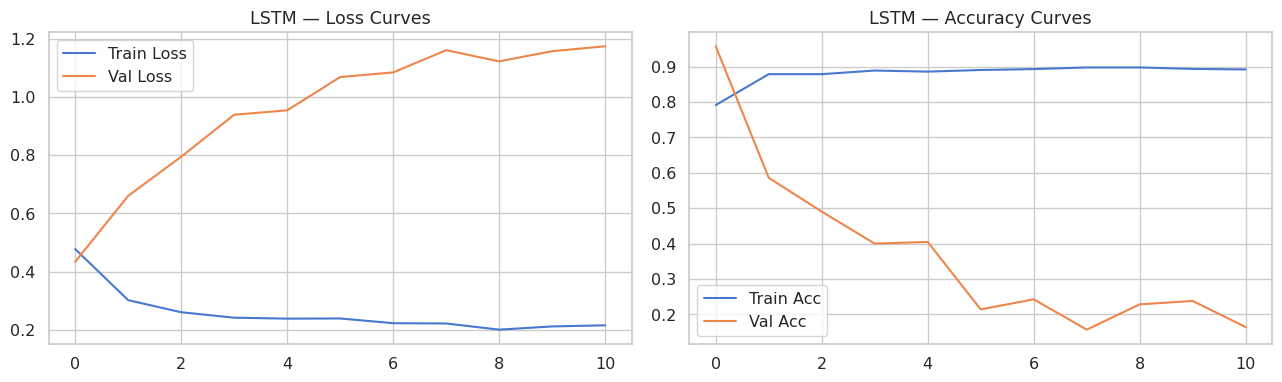


✅ LSTM training complete (11 epochs)


In [30]:
SEQ_LEN = 20  # 20 readings × 5 s = 100-second window

def make_sequences(X: np.ndarray, y: np.ndarray, seq_len: int):
    """Create overlapping sequences: (samples, seq_len, features)."""
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

X_lstm_full = sc2.transform(df_fe[FEATURES_ENG].values)
y_lstm_full = y_eng

X_seq, y_seq = make_sequences(X_lstm_full, y_lstm_full, SEQ_LEN)
print(f"Sequence dataset — X: {X_seq.shape}  y: {y_seq.shape}")

split_tr = int(0.70 * len(X_seq))
split_vl = int(0.85 * len(X_seq))
X_seq_tr, y_seq_tr = X_seq[:split_tr],      y_seq[:split_tr]
X_seq_vl, y_seq_vl = X_seq[split_tr:split_vl], y_seq[split_tr:split_vl]
X_seq_ts, y_seq_ts = X_seq[split_vl:],      y_seq[split_vl:]

def build_lstm(seq_len: int, n_features: int) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        layers.LSTM(32, return_sequences=False, dropout=0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

lstm_model = build_lstm(SEQ_LEN, len(FEATURES_ENG))
lstm_model.summary()

pos = int(y_seq_tr.sum())
neg = len(y_seq_tr) - pos
cw  = {0: 1.0, 1: max(neg / max(pos, 1), 1.0)}

history = lstm_model.fit(
    X_seq_tr, y_seq_tr,
    validation_data=(X_seq_vl, y_seq_vl),
    epochs=60,
    batch_size=64,
    class_weight=cw,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('LSTM — Loss Curves'); ax1.legend()

ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('LSTM — Accuracy Curves'); ax2.legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ LSTM training complete ({len(history.history['loss'])} epochs)")

## 7. Model Evaluation
Evaluate both models on the held-out **test set** using:
- Accuracy, Precision, Recall, F1-Score, ROC-AUC
- Side-by-side confusion matrices


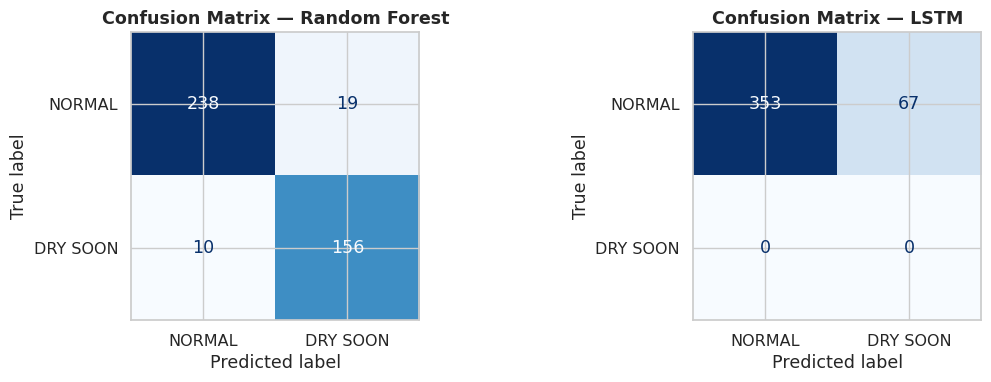

📊 Test Set Classification Reports:

── Random Forest ──
              precision    recall  f1-score   support

      NORMAL     0.9597    0.9261    0.9426       257
    DRY SOON     0.8914    0.9398    0.9150       166

    accuracy                         0.9314       423
   macro avg     0.9256    0.9329    0.9288       423
weighted avg     0.9329    0.9314    0.9317       423

── LSTM ──
              precision    recall  f1-score   support

      NORMAL     1.0000    0.8405    0.9133       420
    DRY SOON     0.0000    0.0000    0.0000         0

    accuracy                         0.8405       420
   macro avg     0.5000    0.4202    0.4567       420
weighted avg     1.0000    0.8405    0.9133       420



In [31]:
# ── Random Forest test predictions
y_rf_pred  = rf_model.predict(X_ts_sc)
y_rf_proba = rf_model.predict_proba(X_ts_sc)[:, 1]

rf_metrics = {
    'Accuracy' : accuracy_score(y_ts, y_rf_pred),
    'Precision': precision_score(y_ts, y_rf_pred, zero_division=0),
    'Recall'   : recall_score(y_ts, y_rf_pred, zero_division=0),
    'F1-Score' : f1_score(y_ts, y_rf_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_ts, y_rf_proba) if len(np.unique(y_ts)) > 1 else float('nan'),
}

# ── LSTM test predictions
y_lstm_proba = lstm_model.predict(X_seq_ts, verbose=0).flatten()
y_lstm_pred  = (y_lstm_proba >= 0.5).astype(int)
y_ts_lstm    = y_seq_ts

lstm_metrics = {
    'Accuracy' : accuracy_score(y_ts_lstm, y_lstm_pred),
    'Precision': precision_score(y_ts_lstm, y_lstm_pred, zero_division=0),
    'Recall'   : recall_score(y_ts_lstm, y_lstm_pred, zero_division=0),
    'F1-Score' : f1_score(y_ts_lstm, y_lstm_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_ts_lstm, y_lstm_proba) if len(np.unique(y_ts_lstm)) > 1 else float('nan'),
}

# ── Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (y_true, y_pred, title) in zip(axes, [
    (y_ts,      y_rf_pred,   'Random Forest'),
    (y_ts_lstm, y_lstm_pred, 'LSTM')
]):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'DRY SOON'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Test Set Classification Reports:")
print("\n── Random Forest ──")
print(classification_report(y_ts,      y_rf_pred,   target_names=['NORMAL','DRY SOON'], digits=4))
print("── LSTM ──")
print(classification_report(y_ts_lstm, y_lstm_pred, target_names=['NORMAL','DRY SOON'], digits=4))

## 8. Model Export
Save trained models for future use and ESP32 edge deployment:
| File | Purpose |
|---|---|
| `rf_irrigation_model.pkl` | Random Forest (scikit-learn) |
| `feature_scaler.pkl` | StandardScaler for inference |
| `lstm_irrigation_model.h5` | Keras LSTM full model |
| `lstm_irrigation_model.tflite` | INT8-quantised TFLite for ESP32 |


In [34]:
joblib.dump(rf_model, 'rf_irrigation_model.pkl')
joblib.dump(sc2,      'feature_scaler.pkl')
print("✅ Saved: rf_irrigation_model.pkl")
print("✅ Saved: feature_scaler.pkl")

lstm_model.save('lstm_irrigation_model.h5')
print("✅ Saved: lstm_irrigation_model.h5")

converter = tf.lite.TFLiteConverter.from_keras_model(lstm_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Fix: Enable SELECT_TF_OPS and disable experimental lowering for TensorList ops
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()
with open('lstm_irrigation_model.tflite', 'wb') as f:
    f.write(tflite_model)
print(f"✅ Saved: lstm_irrigation_model.tflite ({len(tflite_model)/1024:.1f} KB)")

# Verify reload
rf_check = joblib.load('rf_irrigation_model.pkl')
print(f"\nVerification — RF reload OK. Sample prediction: {rf_check.predict(X_ts_sc[:3])}")

✅ Saved: rf_irrigation_model.pkl
✅ Saved: feature_scaler.pkl
✅ Saved: lstm_irrigation_model.h5
Saved artifact at '/tmp/tmpnil5x8yz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 13), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140000205101712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140000205103056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140000205104976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140000205101904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140000205097680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140000205105168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140000205104400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140000205105360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140000205103248: TensorSpec(shape=(), dtype=tf.resource, name=

## 9. Results Summary
Final performance table and bar chart comparing both models on the test set.


   SMART IRRIGATION ML MODEL — PERFORMANCE SUMMARY (Test Set)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.9314,0.8914,0.9398,0.915,0.9889
LSTM,0.8405,0.0000,0.0000,0.000,NaN


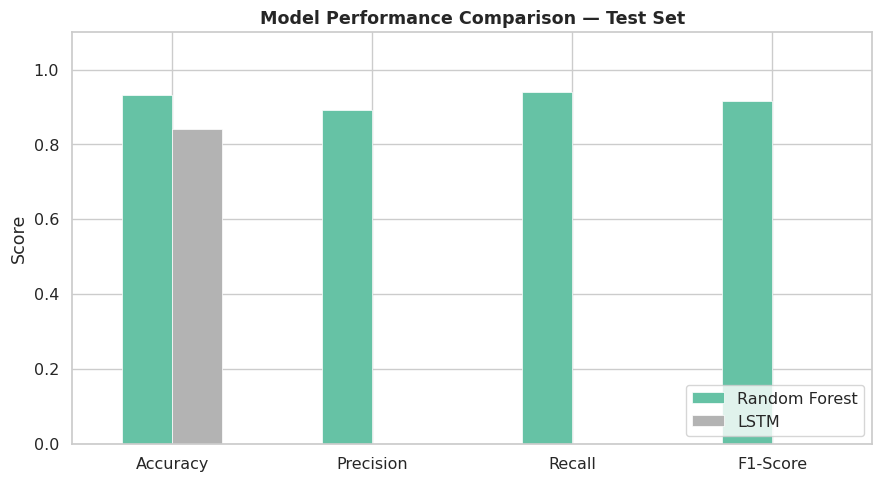


✅ All outputs generated:
   • eda_overview.png
   • rf_feature_importance.png
   • lstm_training_curves.png
   • confusion_matrices.png
   • model_comparison.png
   • rf_irrigation_model.pkl
   • feature_scaler.pkl
   • lstm_irrigation_model.h5
   • lstm_irrigation_model.tflite


In [35]:
results_df = pd.DataFrame({
    'Model'    : ['Random Forest', 'LSTM'],
    'Accuracy' : [rf_metrics['Accuracy'],  lstm_metrics['Accuracy']],
    'Precision': [rf_metrics['Precision'], lstm_metrics['Precision']],
    'Recall'   : [rf_metrics['Recall'],    lstm_metrics['Recall']],
    'F1-Score' : [rf_metrics['F1-Score'],  lstm_metrics['F1-Score']],
    'ROC-AUC'  : [rf_metrics['ROC-AUC'],   lstm_metrics['ROC-AUC']],
}).set_index('Model')

print("=" * 65)
print("   SMART IRRIGATION ML MODEL — PERFORMANCE SUMMARY (Test Set)")
print("=" * 65)
display(results_df.round(4))
print("=" * 65)

# Bar chart
results_df[['Accuracy','Precision','Recall','F1-Score']].T.plot(
    kind='bar', figsize=(9, 5), rot=0, colormap='Set2',
    edgecolor='white', linewidth=0.5)
plt.title('Model Performance Comparison — Test Set', fontweight='bold')
plt.ylabel('Score'); plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All outputs generated:")
for f in ['eda_overview.png','rf_feature_importance.png',
          'lstm_training_curves.png','confusion_matrices.png',
          'model_comparison.png','rf_irrigation_model.pkl',
          'feature_scaler.pkl','lstm_irrigation_model.h5',
          'lstm_irrigation_model.tflite']:
    print(f"   • {f}")